In [ ]:
import pandas as pd
employee=pd.read_csv("D:/dataset/Employee.csv")
employee_training_data=pd.read_csv("D:/dataset/employee_training_dataset.csv")


In [ ]:
print("*****Employee******")
print("shape : ",employee.shape)
print("Column name : ",employee.columns.tolist())
print("DataType : ",employee.dtypes)


In [ ]:
missing_values=employee.isnull().sum()
print("missing number of value : ",missing_values)


In [ ]:
duplicates=employee.duplicated().sum()
print("Duplicates : ",duplicates)


In [ ]:
employee.loc[:,["Name","Age","Salary"]]

In [ ]:
employee.head(10)

In [ ]:
employee.tail(5)

In [ ]:
print(employee[(employee["Age"].between(30,40))&(employee["Department"]=="Engineering")])

In [ ]:
print(employee[(employee["Work_Location"]=="New York")&(employee["Performance_Score"]>8)])

In [ ]:
numeric_col=employee.select_dtypes(include=["number"])
print(numeric_col)


In [ ]:
employee["Gender"]=employee["Gender"].replace({
    "M":"Male",
    "F":"Female"})

In [ ]:
employee["Department"]=employee["Department"].replace({
    "HR":"Human Resources",
    "IT":"Information Technology"
})

In [ ]:
import numpy as np
employee.loc[(employee["Age"] < 0) | (employee["Age"] > 120), "Age"] = np.nan
employee.loc[(employee["Salary"] < 10000) | (employee["Salary"] > 500000), "Salary"] = np.nan

In [ ]:
employee["Gender"]=employee["Gender"].str.title()
employee["Department"] = employee["Department"].str.title()

In [ ]:
employee["Department"] = employee["Department"].replace({
    "Hr": "Human Resources",
    "Human Resources": "Human Resources",
    "It": "Information Technology",
    "Info Tech": "Information Technology"
})

In [ ]:
print("cleaned data:\n",employee)

In [ ]:
data_mean = employee.copy()
data_mean["Age"] = data_mean["Age"].fillna(data_mean["Age"].mean())
data_mean["Salary"] = data_mean["Salary"].fillna(data_mean["Salary"].mean())

In [ ]:
data_median = employee.copy()
data_median["Age"] = data_median["Age"].fillna(data_median["Age"].median())
data_median["Salary"] = data_median["Salary"].fillna(data_median["Salary"].median())

In [ ]:
data_mode = employee.copy()
data_mode["Gender"] = data_mode["Gender"].fillna(data_mode["Gender"].mode()[0])

In [ ]:
print("Data:\n",employee)

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print("IQR Outliers in Age:\n", detect_outliers_iqr(employee, "Age"))
print("\nIQR Outliers in Salary:\n", detect_outliers_iqr(employee, "Salary"))


In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"\n{column} → Q1={Q1}, Q3={Q3}, IQR={IQR}, Bounds=({lower_bound}, {upper_bound})")
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print("IQR Outliers in Age:\n", detect_outliers_iqr(employee, "Age"))
print("\nIQR Outliers in Salary:\n", detect_outliers_iqr(employee, "Salary"))


In [38]:
from scipy.stats import zscore

data = pd.DataFrame({
    "Name": ["Ali", "Sara", "John", "Ayesha", "Omar", "Zara"],
    "Age": [25, 30, 40, 22, 150, 28],          # 150 = outlier
    "Salary": [50000, 70000, 80000, 60000, 12000000, 75000]  # 12M = outlier
})

def detect_outliers_zscore(df, column, threshold=3):
    z_scores = zscore(df[column])
    df["Z_" + column] = z_scores  
    
    outliers = df[np.abs(z_scores) > threshold]
    return outliers

print("Z-score Outliers in Age:\n", detect_outliers_zscore(employee.copy(), "Age"))
print("\nZ-score Outliers in Salary:\n", detect_outliers_zscore(employee.copy(), "Salary"))


Z-score Outliers in Age:
 Empty DataFrame
Columns: [Employee_ID, Name, Age, Department, Salary, Joining_Date, Gender, Experience_Years, Performance_Score, Work_Location, Z_Age]
Index: []

Z-score Outliers in Salary:
 Empty DataFrame
Columns: [Employee_ID, Name, Age, Department, Salary, Joining_Date, Gender, Experience_Years, Performance_Score, Work_Location, Z_Salary]
Index: []


In [39]:
import pandas as pd
import numpy as np

def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

def cap_outliers(df, column):
    lower, upper = iqr_bounds(df[column])
    df[column] = np.where(df[column] < lower, lower,
                 np.where(df[column] > upper, upper, df[column]))
    return df

print("Before:\n", employee.describe())

lower_age, upper_age = iqr_bounds(employee["Age"])
lower_sal, upper_sal = iqr_bounds(employee["Salary"])

removed = employee[(employee["Age"] >= lower_age) & (employee["Age"] <= upper_age) &
                   (employee["Salary"] >= lower_sal) & (employee["Salary"] <= upper_sal)]

print("\nAfter Removing Outliers:\n", removed.describe())

capped = employee.copy()
capped = cap_outliers(capped, "Age")
capped = cap_outliers(capped, "Salary")

print("\nAfter Capping Outliers:\n", capped.describe())


Before:
        Employee_ID         Age         Salary  Experience_Years  \
count   200.000000  192.000000     186.000000        200.000000   
mean    100.500000   41.442708   63021.672043         15.165000   
std      57.879185   13.965809   24569.627939          8.775123   
min       1.000000    0.000000   23216.000000          0.000000   
25%      50.750000   30.000000   53019.250000          7.000000   
50%     100.500000   42.000000   60978.500000         16.500000   
75%     150.250000   54.000000   73065.500000         22.000000   
max     200.000000   64.000000  328480.000000         29.000000   

       Performance_Score  
count         186.000000  
mean            2.801075  
std             1.233847  
min             1.000000  
25%             2.000000  
50%             3.000000  
75%             4.000000  
max             5.000000  

After Removing Outliers:
        Employee_ID         Age        Salary  Experience_Years  \
count   177.000000  177.000000    177.000000       

In [40]:
import pandas as pd
import numpy as np
from scipy import stats

def calculate_stats(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return {
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0],
        "variance": series.var(),
        "std_dev": series.std(),
        "IQR": IQR,
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min()
    }

for col in ["Age", "Salary", "Experience_Years", "Performance_Score"]:
    print(f"\n--- {col} ---")
    print(calculate_stats(employee[col]))



--- Age ---
{'mean': np.float64(41.442708333333336), 'median': 42.0, 'mode': np.float64(56.0), 'variance': 195.04382089877842, 'std_dev': 13.965808995499632, 'IQR': np.float64(24.0), 'min': 0.0, 'max': 64.0, 'range': 64.0}

--- Salary ---
{'mean': np.float64(63021.67204301075), 'median': 60978.5, 'mode': np.float64(23216.0), 'variance': 603666617.075647, 'std_dev': 24569.62793930032, 'IQR': np.float64(20046.25), 'min': 23216.0, 'max': 328480.0, 'range': 305264.0}

--- Experience_Years ---
{'mean': np.float64(15.165), 'median': 16.5, 'mode': np.int64(16), 'variance': 77.00278894472366, 'std_dev': 8.775123300827383, 'IQR': np.float64(15.0), 'min': 0, 'max': 29, 'range': 29}

--- Performance_Score ---
{'mean': np.float64(2.8010752688172045), 'median': 3.0, 'mode': np.float64(3.0), 'variance': 1.5223772159256033, 'std_dev': 1.2338465123043478, 'IQR': np.float64(2.0), 'min': 1.0, 'max': 5.0, 'range': 4.0}


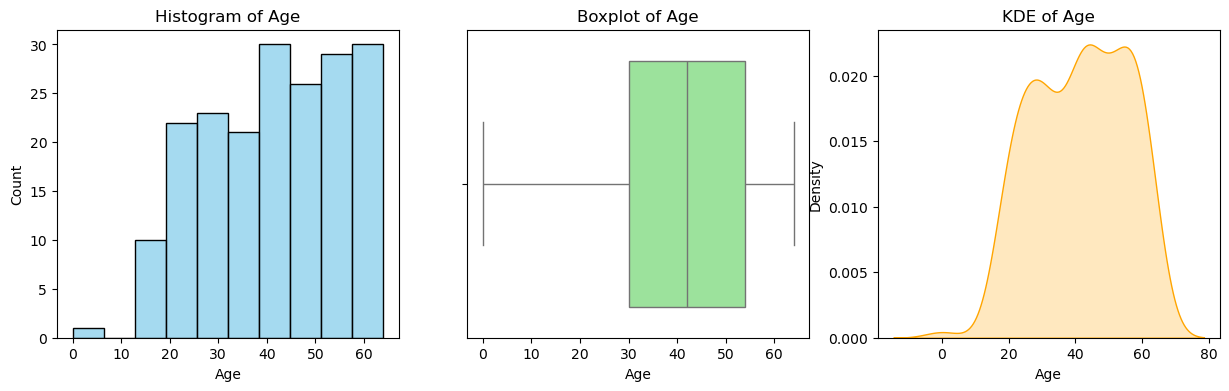

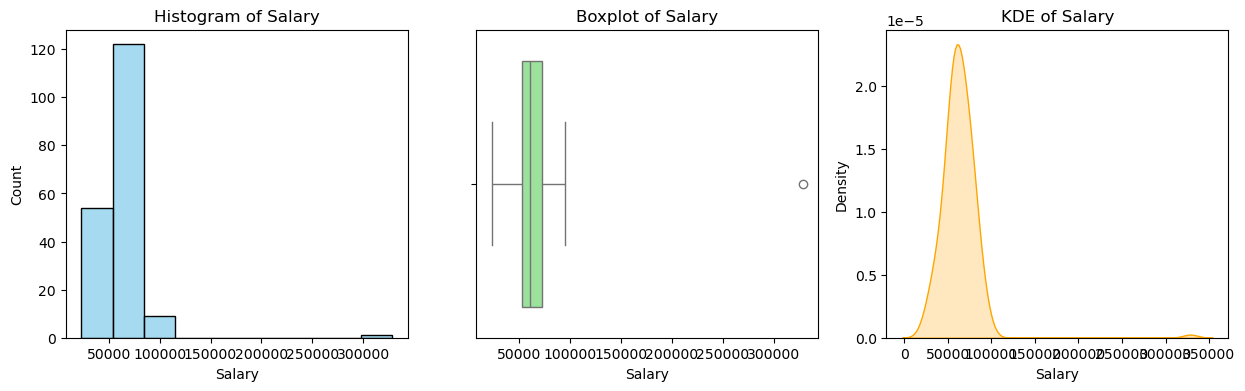

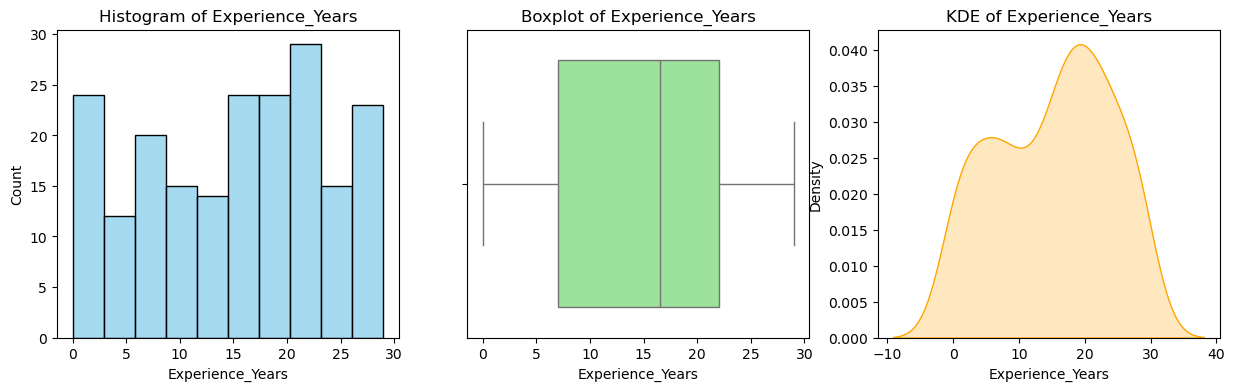

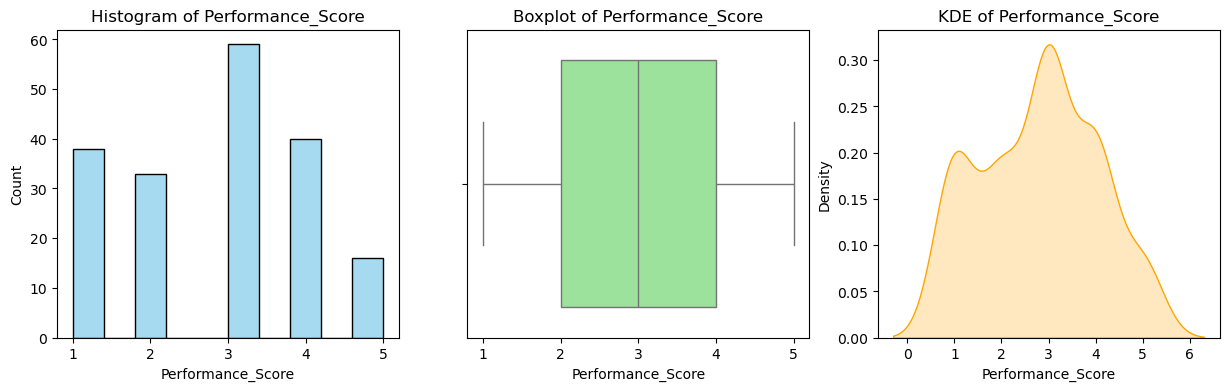

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["Age", "Salary", "Experience_Years", "Performance_Score"]

for col in numeric_cols:
    plt.figure(figsize=(15,4))

    #histogram
    plt.subplot(1,3,1)
    sns.histplot(employee[col], kde=False, bins=10, color="skyblue")
    plt.title(f"Histogram of {col}")

    # boxplot
    plt.subplot(1,3,2)
    sns.boxplot(x=employee[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")

    # KDE plot
    plt.subplot(1,3,3)
    sns.kdeplot(employee[col], fill=True, color="orange")
    plt.title(f"KDE of {col}")

    plt.show()


In [42]:
from sklearn.preprocessing import PowerTransformer

for col in numeric_cols:
    skew = employee[col].skew()
    print(f"{col}: Skewness = {skew:.2f}")
employee_log = employee[numeric_cols].apply(lambda x: np.log1p(x))

pt_boxcox = PowerTransformer(method="box-cox", standardize=False)  
pt_yeo = PowerTransformer(method="yeo-johnson", standardize=False)

employee_yeo = pd.DataFrame(pt_yeo.fit_transform(employee[numeric_cols]),
                            columns=[c+"_yeo" for c in numeric_cols])
print("\nAfter Yeo-Johnson Transformation (first 5 rows):")
print(employee_yeo.head())


Age: Skewness = -0.19
Salary: Skewness = 6.78
Experience_Years: Skewness = -0.20
Performance_Score: Skewness = 0.00

After Yeo-Johnson Transformation (first 5 rows):
     Age_yeo  Salary_yeo  Experience_Years_yeo  Performance_Score_yeo
0  67.732262    6.911482             13.635082               2.533433
1  55.025331    7.053219             16.702356               0.925388
2  37.520068         NaN             17.303650               3.978804
3  72.854512    6.910722              7.767981               3.270883
4  28.926228    7.186179              4.185679               3.270883


In [44]:
avg_salary_dept = employee.groupby("Department")["Salary"].mean()
print("Average Salary per Department:\n", avg_salary_dept)
avg_perf_gender = employee.groupby("Gender")["Performance_Score"].mean()
print("\nAverage Performance Score per Gender:\n", avg_perf_gender)
exp_stats_location = employee.groupby("Work_Location")["Experience_Years"].agg(["min", "max", "mean"])
print("\nExperience Stats per Location:\n", exp_stats_location)

Average Salary per Department:
 Department
Finance                   68856.763158
Human Resources           64036.916667
Information Technology    60764.297872
Marketing                 58813.865385
Operations                66173.800000
Name: Salary, dtype: float64

Average Performance Score per Gender:
 Gender
Female    2.681319
Male      2.948718
Name: Performance_Score, dtype: float64

Experience Stats per Location:
                min  max       mean
Work_Location                     
Berlin           1   28  16.125000
London           0   29  14.842105
New York         0   29  16.309091
Remote           0   29  14.027027
Tokyo            0   29  14.131579


In [45]:
summary_stats = employee.groupby("Department").agg({
    "Salary": ["mean", "median", "std"],
    "Age": ["mean", "median", "std"]
})
print("\nSummary Table for Salary & Age by Department:\n", summary_stats)



Summary Table for Salary & Age by Department:
                               Salary                               Age         \
                                mean   median           std       mean median   
Department                                                                      
Finance                 68856.763158  65752.0  45279.075528  40.540541   41.0   
Human Resources         64036.916667  62106.5  13481.257769  43.458333   39.5   
Information Technology  60764.297872  59779.0  15187.546709  41.480000   43.5   
Marketing               58813.865385  58313.0  15046.409696  41.000000   42.0   
Operations              66173.800000  65437.0  16779.563257  41.655172   42.0   

                                   
                              std  
Department                         
Finance                 15.894784  
Human Resources         13.383894  
Information Technology  13.542435  
Marketing               13.102911  
Operations              14.828245  


In [47]:
pivot_salary = pd.pivot_table(employee,
                              values="Salary",
                              index="Department",
                              columns="Gender",
                              aggfunc="mean")
print("\nPivot Table - Avg Salary by Department & Gender:\n", pivot_salary)

pivot_perf = pd.pivot_table(employee,
                            values="Performance_Score",
                            index="Department",
                            columns="Work_Location",
                            aggfunc="mean")
print("\nPivot Table - Avg Performance Score by Department & Location:\n", pivot_perf)



Pivot Table - Avg Salary by Department & Gender:
 Gender                        Female          Male
Department                                        
Finance                 64064.294118  77789.647059
Human Resources         63564.333333  64320.466667
Information Technology  64247.458333  57172.052632
Marketing               57857.142857  59850.636364
Operations              65466.176471  69793.714286

Pivot Table - Avg Performance Score by Department & Location:
 Work_Location             Berlin    London  New York    Remote     Tokyo
Department                                                              
Finance                 1.666667  3.125000  2.875000  3.500000  3.000000
Human Resources         4.200000  3.600000  2.000000  4.000000  3.000000
Information Technology  2.166667  3.000000  2.846154  2.666667  2.545455
Marketing               2.272727  2.888889  2.923077  2.727273  2.666667
Operations              2.800000  3.333333  2.384615  2.000000  2.333333


In [48]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

# --- Before encoding ---
print("Shape before encoding:", employee.shape)


le = LabelEncoder()
employee["Gender_Label"] = le.fit_transform(employee["Gender"])  
#  Male=1, Female=0

employee_encoded = pd.get_dummies(employee, columns=["Department"], prefix="Dept")

# --- After encoding ---
print("Shape after encoding:", employee_encoded.shape)
print(employee_encoded.head())


Shape before encoding: (200, 10)
Shape after encoding: (200, 15)
   Employee_ID   Name   Age   Salary Joining_Date  Gender  Experience_Years  \
0            1  Emp_1  56.0  40575.0    1/31/2015  Female                19   
1            2  Emp_2  46.0  58423.0    2/28/2015    Male                24   
2            3  Emp_3  32.0      NaN    3/31/2015  Female                25   
3            4  Emp_4  60.0  40497.0    4/30/2015  Female                10   
4            5  Emp_5  25.0  83146.0    5/31/2015    Male                 5   

   Performance_Score Work_Location  Gender_Label  Dept_Finance  \
0                3.0         Tokyo             0          True   
1                1.0        Remote             1         False   
2                5.0      New York             0         False   
3                4.0        Remote             0          True   
4                4.0        Remote             1         False   

   Dept_Human Resources  Dept_Information Technology  Dept_Mark

In [49]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Select numerical columns
num_cols = ["Age", "Salary", "Experience_Years"]

minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

employee_scaled = employee_encoded.copy()
employee_scaled[["Age_MinMax", "Salary_MinMax", "Exp_MinMax"]] = minmax.fit_transform(employee_scaled[num_cols])
employee_scaled[["Age_Std", "Salary_Std", "Exp_Std"]] = standard.fit_transform(employee_scaled[num_cols])
employee_scaled[["Age_Robust", "Salary_Robust", "Exp_Robust"]] = robust.fit_transform(employee_scaled[num_cols])


In [50]:
comparison = employee_scaled[["Age", "Salary", "Experience_Years",
                              "Age_MinMax", "Salary_MinMax", "Exp_MinMax",
                              "Age_Std", "Salary_Std", "Exp_Std",
                              "Age_Robust", "Salary_Robust", "Exp_Robust"]].head()

print("\nOriginal vs Scaled Values:\n", comparison)



Original vs Scaled Values:
     Age   Salary  Experience_Years  Age_MinMax  Salary_MinMax  Exp_MinMax  \
0  56.0  40575.0                19    0.875000       0.056866    0.655172   
1  46.0  58423.0                24    0.718750       0.115333    0.827586   
2  32.0      NaN                25    0.500000            NaN    0.862069   
3  60.0  40497.0                10    0.937500       0.056610    0.344828   
4  25.0  83146.0                 5    0.390625       0.196322    0.172414   

    Age_Std  Salary_Std   Exp_Std  Age_Robust  Salary_Robust  Exp_Robust  
0  1.045077   -0.916060  0.438128    0.583333      -1.017821    0.166667  
1  0.327171   -0.187674  1.009350    0.166667      -0.127480    0.500000  
2 -0.677898         NaN  1.123594   -0.416667            NaN    0.566667  
3  1.332240   -0.919243 -0.590073    0.750000      -1.021712   -0.433333  
4 -1.180433    0.821284 -1.161295   -0.708333       1.105818   -0.766667  


In [53]:
employee_training_data=pd.read_csv("D:/dataset/employee_training_dataset.csv")

In [55]:
merged_df = pd.merge(employee, employee_training_dataset, on="Employee_ID", how="inner")

print("Merged Dataset Shape:", merged_df.shape)
print(merged_df.head())


NameError: name 'employee_training_dataset' is not defined

In [56]:
print("employee_training_dataset")

employee_training_dataset


In [57]:
print(employee_training_dataset)

NameError: name 'employee_training_dataset' is not defined

In [4]:
employee_training=pd.read_csv("D:/dataset/employee_training_dataset.csv")

In [5]:
print(employee_training_dataset)

NameError: name 'employee_training_dataset' is not defined

In [60]:
print(employee_training_dataset)


NameError: name 'employee_training_dataset' is not defined

In [6]:
import pandas as pd
employeeTrainingData=pd.read_csv("D:/dataset/employee_training_dataset.csv")

In [7]:
employeeTrainingData.head(10)


,Employee_ID,Training_Hours,Certification_Status
0,E001,25,Completed
1,E002,15,Pending
2,E003,30,Completed
3,E004,12,Pending
4,E005,20,Completed
5,E006,18,Pending
6,E007,40,Completed
7,E008,10,Pending
8,E009,22,Completed
9,E010,35,Completed


In [8]:
employee=pd.read_csv("D:/dataset/employee.csv")


In [9]:
employee.head(10)

,Employee_ID,Name,Age,Department,Salary,Joining_Date,Gender,Experience_Years,Performance_Score,Work_Location
0,1,Emp_1,56.0,Finance,40575.0,1/31/2015,Female,19,3.0,Tokyo
1,2,Emp_2,46.0,IT,58423.0,2/28/2015,M,24,1.0,Remote
2,3,Emp_3,32.0,IT,NaN,3/31/2015,Female,25,5.0,New York
3,4,Emp_4,60.0,Finance,40497.0,4/30/2015,Female,10,4.0,Remote
4,5,Emp_5,25.0,HR,83146.0,5/31/2015,M,5,4.0,Remote
5,6,Emp_6,38.0,Marketing,79848.0,6/30/2015,Male,1,4.0,New York
6,7,Emp_7,56.0,IT,NaN,7/31/2015,Male,6,3.0,Remote
7,8,Emp_8,36.0,HR,53015.0,8/31/2015,M,17,4.0,Tokyo
8,9,Emp_9,40.0,Finance,60877.0,9/30/2015,F,26,3.0,Remote
9,10,Emp_10,28.0,Operations,95219.0,10/31/2015,Female,1,1.0,Tokyo


In [10]:
employeeTrainingData["Employee_ID"]=employeeTrainingData["Employee_ID"].str.replace("E","").astype(int)

In [11]:
employeeTrainingData.head(10)

,Employee_ID,Training_Hours,Certification_Status
0,1,25,Completed
1,2,15,Pending
2,3,30,Completed
3,4,12,Pending
4,5,20,Completed
5,6,18,Pending
6,7,40,Completed
7,8,10,Pending
8,9,22,Completed
9,10,35,Completed


In [12]:
print(employee["Employee_ID"].dtype)

int64


In [13]:
merged_df = pd.merge(employee, employeeTrainingData, on="Employee_ID", how="inner")

In [15]:
merged_df.head(10)

,Employee_ID,Name,Age,Department,Salary,Joining_Date,Gender,Experience_Years,Performance_Score,Work_Location,Training_Hours,Certification_Status
0,1,Emp_1,56.0,Finance,40575.0,1/31/2015,Female,19,3.0,Tokyo,25,Completed
1,2,Emp_2,46.0,IT,58423.0,2/28/2015,M,24,1.0,Remote,15,Pending
2,3,Emp_3,32.0,IT,NaN,3/31/2015,Female,25,5.0,New York,30,Completed
3,4,Emp_4,60.0,Finance,40497.0,4/30/2015,Female,10,4.0,Remote,12,Pending
4,5,Emp_5,25.0,HR,83146.0,5/31/2015,M,5,4.0,Remote,20,Completed
5,6,Emp_6,38.0,Marketing,79848.0,6/30/2015,Male,1,4.0,New York,18,Pending
6,7,Emp_7,56.0,IT,NaN,7/31/2015,Male,6,3.0,Remote,40,Completed
7,8,Emp_8,36.0,HR,53015.0,8/31/2015,M,17,4.0,Tokyo,10,Pending
8,9,Emp_9,40.0,Finance,60877.0,9/30/2015,F,26,3.0,Remote,22,Completed
9,10,Emp_10,28.0,Operations,95219.0,10/31/2015,Female,1,1.0,Tokyo,35,Completed


In [16]:
merged_df["Salary_per_TrainingHour"] = merged_df["Salary"] / merged_df["Training_Hours"].replace(0, 1) 

In [17]:
print(merged_df[["Employee_ID","Salary"]])

   Employee_ID   Salary
0            1  40575.0
1            2  58423.0
2            3      NaN
3            4  40497.0
4            5  83146.0
5            6  79848.0
6            7      NaN
7            8  53015.0
8            9  60877.0
9           10  95219.0


In [18]:
salary_comparison = merged_df.groupby("Certification_Status")["Salary"].agg(["mean", "median", "count"])

In [19]:
print("\nSalary Comparison (Completed vs Pending Certifications):\n", salary_comparison)


Salary Comparison (Completed vs Pending Certifications):
                           mean   median  count
Certification_Status                          
Completed             69954.25  72011.5      4
Pending               57945.75  55719.0      4
